# mobility_lag_sensitivity

This notebook is to analyze the outputs from experiment ran from `../expermiments/20260328_mobility_lag_sensitivity`.

The Advan mobility data source refreshes monthly, meaning up to 4 weeks of data at
the forecast frontier may not yet be published in a real-time setting. This experiment
tests the sensitivity of the CDCRNN model — and its GNNExplainer edge importance
outputs — to this data availability constraint.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from cgnn.explain import load_aggregate_ts_from_cfg, compute_lead_lag

## Plot z-score time series

In [2]:
HOSP_CFG_FILE = "/burg/apam/users/nhw2114/repos/cgnn/models/gcn_checkpoints/hospital_advan_plus_cdcrnn_h1_lr1e-05_hs16/config.yaml"
hosp_ts, hosp_dates = load_aggregate_ts_from_cfg(HOSP_CFG_FILE)

Loading hospitalization data...


/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:988: DtypeWarning: Columns (0: hospital_pk, 1: ccn) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(raw_hospitalization_file, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4930
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
Loading mobility data (source=advan_plus)...


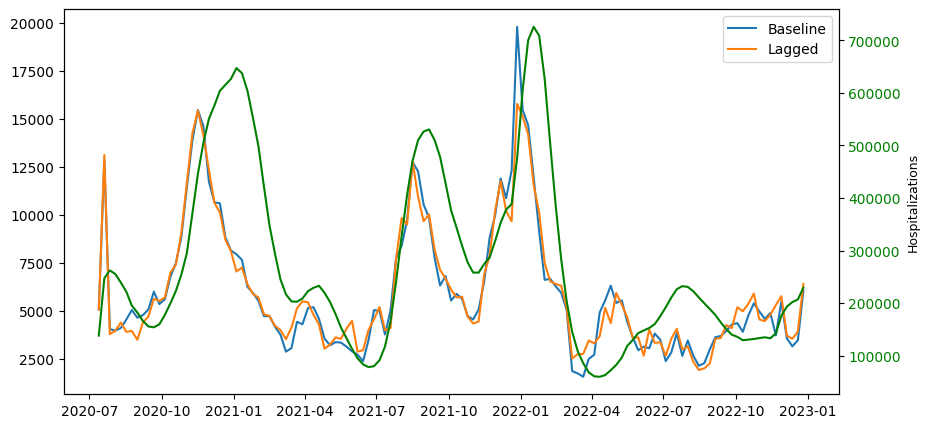

In [9]:
baseline_version = Path("../plots/moblag_fig1_baseline/")
lagged_version = Path("../plots/moblag_fig1_monthly_lag/")

baseline_edge_count_df = pd.read_csv(baseline_version / "explain_count.csv")
lagged_edge_count_df = pd.read_csv(lagged_version / "explain_count.csv")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hosp_dates, baseline_edge_count_df.num_explainable_edges, label="Baseline")
ax.plot(hosp_dates, lagged_edge_count_df.num_explainable_edges, label="Lagged")

ax2 = ax.twinx()
ax2.plot(hosp_dates, hosp_ts, color='green', linewidth=1.5)
ax2.set_ylabel("Hospitalizations", fontsize=9)
ax2.tick_params(axis="y", labelcolor='green')

ax.legend()
plt.show()



In [ ]:
h

,snapshot_idx,split,num_explainable_edges
0,0,train,5081
1,1,train,12854
2,2,train,4063
3,3,train,3978
4,4,train,4117
...,...,...,...
124,124,test,5500
125,125,test,3579
126,126,test,3162
127,127,test,3480


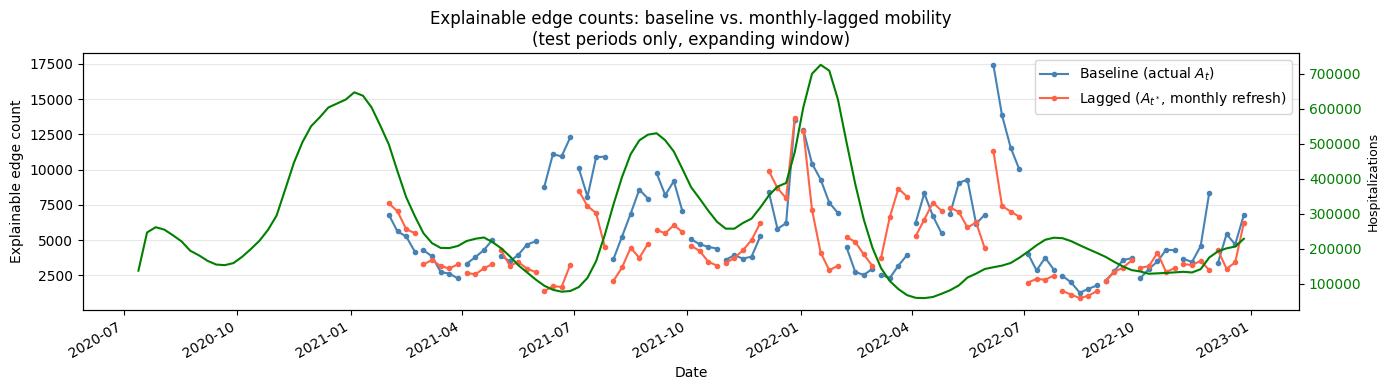

In [19]:
PLOTS_DIR = Path("../plots")
START_DATE = "2020-07-13"

# Fold definitions: (fold_id, end_date)
FOLDS = [
    ("2021_02", "2021-02-28"),
    ("2021_03", "2021-03-31"),
    ("2021_04", "2021-04-30"),
    ("2021_05", "2021-05-31"),
    ("2021_06", "2021-06-30"),
    ("2021_07", "2021-07-31"),
    ("2021_08", "2021-08-31"),
    ("2021_09", "2021-09-30"),
    ("2021_10", "2021-10-31"),
    ("2021_11", "2021-11-30"),
    ("2021_12", "2021-12-31"),
    ("2022_01", "2022-01-31"),
    ("2022_02", "2022-02-28"),
    ("2022_03", "2022-03-31"),
    ("2022_04", "2022-04-30"),
    ("2022_05", "2022-05-31"),
    ("2022_06", "2022-06-30"),
    ("2022_07", "2022-07-31"),
    ("2022_08", "2022-08-31"),
    ("2022_09", "2022-09-30"),
    ("2022_10", "2022-10-31"),
    ("2022_11", "2022-11-30"),
    ("2022_12", "2022-12-31"),
]

def load_fold(fold_id, end_date, condition):
    """Load test-period explain_count for one fold and condition."""
    version = f"moblag_monthly_fold_{fold_id}" if condition == "baseline" else f"moblag_monthly_lag_{fold_id}_epochs2000"
    fpath = PLOTS_DIR / version / "explain_count.csv"
    if not fpath.exists():
        print(f"  Missing: {fpath}")
        return None

    # Reconstruct weekly Monday dates for this fold
    dates = pd.date_range(start=START_DATE, end=end_date, freq="W-MON")

    df = pd.read_csv(fpath)
    df = df[df["split"] == "test"].copy()
    df["date"] = df["snapshot_idx"].map(lambda i: dates[i])
    df["fold"] = fold_id
    df["condition"] = condition
    return df[["date", "fold", "condition", "num_explainable_edges"]]


records = []
for fold_id, end_date in FOLDS:
    for condition in ("baseline", "lagged"):
        result = load_fold(fold_id, end_date, condition)
        if result is not None:
            records.append(result)

combined = pd.concat(records, ignore_index=True).sort_values(["condition", "fold", "date"])

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 4))

# For each condition, plot per fold (not connecting the folds)
for condition, color, label in [
    ("baseline", "steelblue", "Baseline (actual $A_t$)"),
    ("lagged",   "tomato",    "Lagged ($A_{t^*}$, monthly refresh)"),
]:
    condition_df = combined[combined["condition"] == condition]
    first = True
    for fold_id, _ in FOLDS:
        fold_df = condition_df[condition_df["fold"] == fold_id]
        if not fold_df.empty:
            # Plot a line for within-fold, not connecting to next fold
            ax.plot(
                fold_df["date"], fold_df["num_explainable_edges"],
                color=color,
                linewidth=1.5,
                marker="o",
                markersize=3,
                label=label if first else None,
            )
            first = False

ax2 = ax.twinx()
ax2.plot(hosp_dates, hosp_ts, color='green', linewidth=1.5)
ax2.set_ylabel("Hospitalizations", fontsize=9)
ax2.tick_params(axis="y", labelcolor='green')

ax.set_xlabel("Date")
ax.set_ylabel("Explainable edge count")
ax.set_title("Explainable edge counts: baseline vs. monthly-lagged mobility\n(test periods only, expanding window)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# fig.savefig("mobility_lag_sensitivity.png")

In [4]:
compute_lead_lag(combined.loc[combined["condition"] == "lagged", "num_explainable_edges"], hosp_ts[29:], max_lag=10)

(array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 array([-0.00289381,  0.08790803,  0.18373712,  0.27531037,  0.35216692,
         0.4034061 ,  0.41769437,  0.38860604,  0.33068699,  0.26301662,
         0.18824337,  0.10026774,  0.0413885 ,  0.0107246 , -0.01516458,
        -0.01980179, -0.00984928,  0.02232627,  0.0768681 ,  0.1427181 ,
         0.22037173]),
 -4,
 0.41769437413907645)

In [5]:
compute_lead_lag(combined.loc[combined["condition"] == "baseline", "num_explainable_edges"], hosp_ts[29:], max_lag=10)

(array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 array([ 0.19082967,  0.23564248,  0.28039043,  0.32037527,  0.35207971,
         0.37553414,  0.38172363,  0.36756339,  0.33649765,  0.28345666,
         0.20066539,  0.09296549, -0.00671096, -0.10360514, -0.19428777,
        -0.27301335, -0.32510292, -0.3430123 , -0.33206386, -0.2918387 ,
        -0.22922141]),
 -4,
 0.38172362775148233)

# Load model checkpoint

In [3]:
MODEL_CHECKPOINT = "/burg/apam/users/nhw2114/repos/cgnn/models/gcn_checkpoints/hospital_advan_plus_cdcrnn_h1_lr1e-05_hs16/cdcrnn_final_model.pt"

import torch
from cgnn.model import CDCRNN

# The hyperparameters used to construct the model must match those used during training.
# Reference: see `main_new_model.py` for model args at load:
# node_features, target_horizon, predict_delta, hidden_size, K

checkpoint = torch.load(MODEL_CHECKPOINT, map_location="cpu")
hidden_size = checkpoint["hidden_size"] if "hidden_size" in checkpoint else 16
learning_rate = checkpoint.get("learning_rate", 1e-5)
target_horizon = checkpoint.get("target_horizon", 1)  # default: 1
node_features = 4  # adjust if needed: depends on data (e.g., hospital targets=1)
predict_delta = False  # set True if trained with predict_delta

# If you know which were used, update them above. Else, reference config!

# K is the diffusion steps, default to 2 if not in checkpoint
K = checkpoint.get("K", 2)

model = CDCRNN(
    node_features=node_features,
    target_horizon=target_horizon,
    predict_delta=predict_delta,
    hidden_size=hidden_size,
    K=K,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

CDCRNN(
  (recurrent): DCRNN(
    (conv_x_z): DConv(20, 16)
    (conv_x_r): DConv(20, 16)
    (conv_x_h): DConv(20, 16)
  )
  (linear): Linear(in_features=16, out_features=1, bias=True)
)

In [20]:
# Get the dimensions of the convolutional filters in the model (CDCRNN)
conv_layers = []
if hasattr(model, "recurrent") and hasattr(model.recurrent, "conv_x_z"):
    conv_layers.append(model.recurrent.conv_x_z)
if hasattr(model, "recurrent") and hasattr(model.recurrent, "conv_x_r"):
    conv_layers.append(model.recurrent.conv_x_r)
if hasattr(model, "recurrent") and hasattr(model.recurrent, "conv_x_h"):
    conv_layers.append(model.recurrent.conv_x_h)

for i, conv in enumerate(conv_layers):
    weight = getattr(conv, "weight", None)
    if weight is not None:
        print(f"conv_x_{['z','r','h'][i]}: weight.shape = {weight.shape}")
    else:
        print(f"conv_x_{['z','r','h'][i]}: 'weight' attribute not found")

conv_x_z: weight.shape = torch.Size([2, 2, 20, 16])
conv_x_r: weight.shape = torch.Size([2, 2, 20, 16])
conv_x_h: weight.shape = torch.Size([2, 2, 20, 16])


## Rank-correlation and Jaccard overlap of importance edges per test snapshot

In [7]:
baseline_importance_df = pd.read_parquet(f"{baseline_version}/importance_masks.parquet")
seed_version_list = []
for seed in seeds:
    seed_version = f"../plots/moblag_v3_seed{seed}"
    df = pd.read_parquet(f"{seed_version}/importance_masks.parquet")
    df["seed"] = seed
    seed_version_list.append(df)
seed_importance_df = pd.concat(seed_version_list)
lagged_importance_df = pd.read_parquet(f"{lagged_version}/importance_masks.parquet")

baseline_importance_df = baseline_importance_df.loc[baseline_importance_df["split"] == "test"]
seed_importance_df = seed_importance_df.loc[seed_importance_df["split"] == "test"]
lagged_importance_df = lagged_importance_df.loc[lagged_importance_df["split"] == "test"]

Compare count of edges in test snapshot

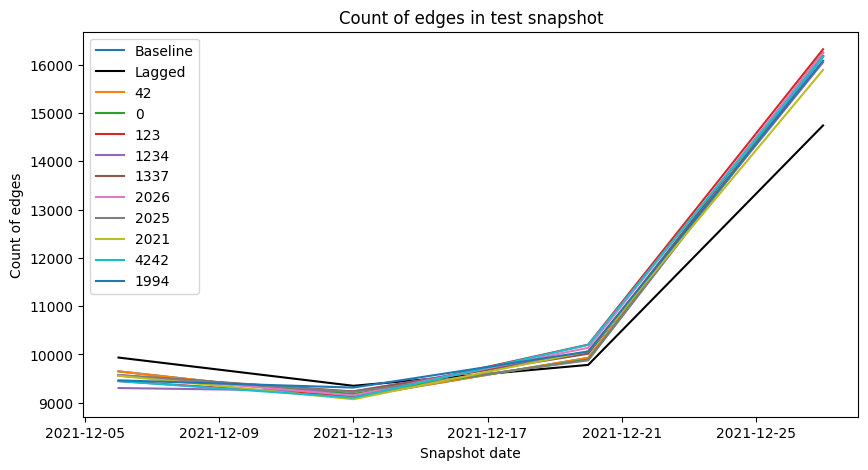

In [8]:
seed_edge_count_df = seed_importance_df.loc[seed_importance_df["importance"] > 0.5].groupby(["seed","date"]).size().reset_index().rename(columns={0: "seed_count"})

edge_count_df = baseline_importance_df.loc[baseline_importance_df["importance"] > 0.5].groupby("date").size().reset_index().rename(columns={0: "baseline_count"}).merge(
    lagged_importance_df.loc[lagged_importance_df["importance"] > 0.5].groupby("date").size().reset_index().rename(columns={0: "lagged_count"}),
    on="date",
)


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(edge_count_df.date, edge_count_df.baseline_count, label="Baseline")
ax.plot(edge_count_df.date, edge_count_df.lagged_count, label="Lagged", color="black")

for seed in seeds:
    sub_seed_count_df = seed_edge_count_df.loc[seed_edge_count_df["seed"] == seed]
    ax.plot(sub_seed_count_df.date, sub_seed_count_df.seed_count, label=seed)
ax.set_title("Count of edges in test snapshot")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Count of edges")
ax.legend()
plt.show()

In [25]:
import scipy
confidence = 0.95
t_value = scipy.stats.t.ppf((1 + confidence) / 2.0, df=len(seeds) - 1)

mean_df = seed_edge_count_df.groupby(["date"])["seed_count"].mean()
std_df = seed_edge_count_df.groupby(["date"])["seed_count"].std()

ci_df = (mean_df - t_value / np.sqrt(len(seeds)) * std_df).round(1).reset_index().merge(
    (mean_df + t_value / np.sqrt(len(seeds)) * std_df).round(1).reset_index(),
    on="date"
)

ci_df

,date,seed_count_x,seed_count_y
0,2021-12-06,9444.4,9585.4
1,2021-12-13,9123.2,9230.4
2,2021-12-20,9959.4,10126.4
3,2021-12-27,16068.7,16241.5


In [41]:
seed_prop_df = seed_edge_count_df.merge(total_edge_count_df, on="date", how="left")
seed_prop_df["seed_prop"] = seed_prop_df["seed_count"] / seed_prop_df["total_baseline_count"]


mean_df = seed_prop_df.groupby(["date"])["seed_prop"].mean()
std_df = seed_prop_df.groupby(["date"])["seed_prop"].std()

ci_df = (mean_df - t_value / np.sqrt(len(seeds)) * std_df).round(4).reset_index().merge(
    (mean_df + t_value / np.sqrt(len(seeds)) * std_df).round(4).reset_index(),
    on="date"
)

ci_df


,date,seed_prop_x,seed_prop_y
0,2021-12-06,0.2867,0.2910
1,2021-12-13,0.2428,0.2457
2,2021-12-20,0.2240,0.2277
3,2021-12-27,0.3124,0.3158


In [43]:
mean_df

date
2021-12-06    0.288855
2021-12-13    0.244259
2021-12-20    0.225871
2021-12-27    0.314118
Name: seed_prop, dtype: float64

Check number of edges in test period

In [32]:
baseline_importance_df = pd.read_parquet(f"{baseline_version}/importance_masks.parquet")
lagged_importance_df = pd.read_parquet(f"{lagged_version}/importance_masks.parquet")

total_edge_count_df = baseline_importance_df.loc[baseline_importance_df["split"] == "test"].groupby("date").size().reset_index().rename(columns={0: "total_baseline_count"}).merge(
    lagged_importance_df.loc[lagged_importance_df["split"] == "test"].groupby("date").size().reset_index().rename(columns={0: "total_lagged_count"}),
    on="date",
)

In [42]:
all_edge_counts_df = total_edge_count_df.merge(edge_count_df, on="date", how="left")
all_edge_counts_df["baseline_edge_ratio"] = all_edge_counts_df["baseline_count"] / all_edge_counts_df["total_baseline_count"]
all_edge_counts_df["lagged_edge_ratio"] = all_edge_counts_df["lagged_count"] / all_edge_counts_df["total_lagged_count"]
all_edge_counts_df

,date,total_baseline_count,total_lagged_count,baseline_count,lagged_count,baseline_edge_ratio,lagged_edge_ratio
0,2021-12-06,32940,33226,9650,9936,0.292957,0.299043
1,2021-12-13,37570,33226,9116,9351,0.242640,0.281436
2,2021-12-20,44463,33226,9929,9784,0.223309,0.294468
3,2021-12-27,51430,33226,16181,14744,0.314622,0.443749


Jaccard overlap

In [19]:
jaccard_overlap = []
for date in baseline_importance_df.date.unique():
    baseline_edges = baseline_importance_df.loc[baseline_importance_df["date"] == date]
    lagged_edges = lagged_importance_df.loc[lagged_importance_df["date"] == date]

    baseline_edges["cbsa_pair"] = baseline_edges["cbsa_orig"].astype(str) + "_" + baseline_edges["cbsa_dest"].astype(str)
    lagged_edges["cbsa_pair"] = lagged_edges["cbsa_orig"].astype(str) + "_" + lagged_edges["cbsa_dest"].astype(str)

    baseline_edges = baseline_edges.loc[baseline_edges["importance"] > 0.5, "cbsa_pair"]
    lagged_edges = lagged_edges.loc[lagged_edges["importance"] > 0.5, "cbsa_pair"]
    jaccard_overlap.append(len(set(baseline_edges) & set(lagged_edges)) / len(set(baseline_edges) | set(lagged_edges)))
    # print(f"Jaccard overlap for {date}: {len(set(baseline_edges) & set(lagged_edges)) / len(set(baseline_edges) | set(lagged_edges))}")


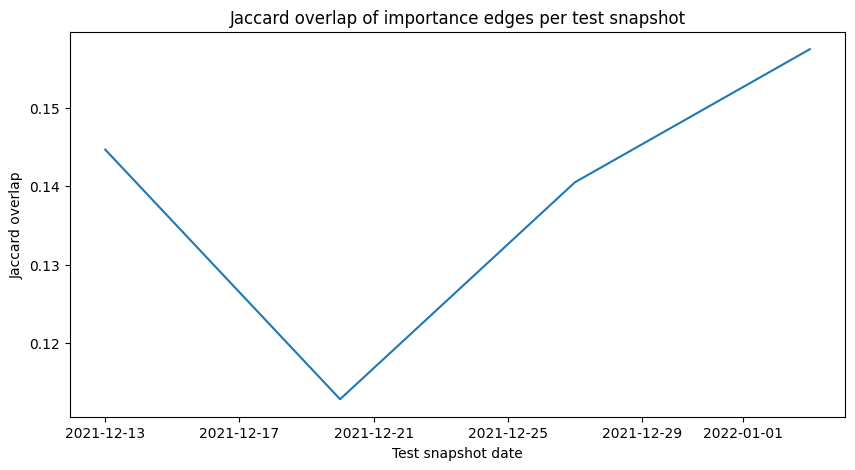

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_importance_df.date.unique()[-4:], jaccard_overlap[-4:])
ax.set_title("Jaccard overlap of importance edges per test snapshot")
ax.set_xlabel("Test snapshot date")
ax.set_ylabel("Jaccard overlap")
plt.show()

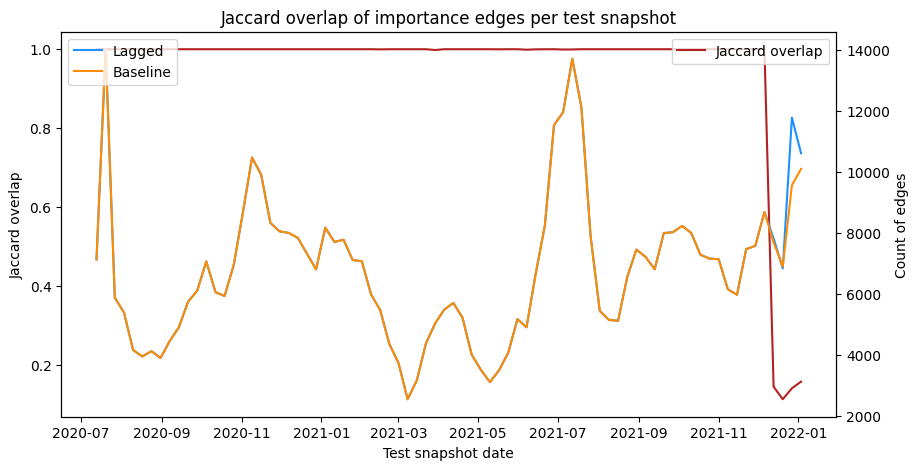

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_importance_df.date.unique(), jaccard_overlap, color="firebrick", label="Jaccard overlap")
ax.legend(loc="upper right")


ax_2 = ax.twinx()
ax_2.plot(edge_count_df.date, edge_count_df.lagged_count, label="Lagged", color="dodgerblue")
ax_2.plot(edge_count_df.date, edge_count_df.baseline_count, label="Baseline", color="darkorange")

ax.set_title("Jaccard overlap of importance edges per test snapshot")
ax.set_xlabel("Test snapshot date")
ax.set_ylabel("Jaccard overlap")
ax_2.set_ylabel("Count of edges")

ax_2.legend(loc="upper left")
plt.show()


## Spearman rank correlation 

In [22]:
from scipy.stats import spearmanr

spearman_corrs = []
for date in baseline_importance_df.date.unique():
    bl = baseline_importance_df.loc[baseline_importance_df["date"] == date].copy()
    lg = lagged_importance_df.loc[lagged_importance_df["date"] == date].copy()

    bl["cbsa_pair"] = bl["cbsa_orig"].astype(str) + "_" + bl["cbsa_dest"].astype(str)
    lg["cbsa_pair"] = lg["cbsa_orig"].astype(str) + "_" + lg["cbsa_dest"].astype(str)

    # Inner join: only edges present in both graphs
    merged = bl[["cbsa_pair", "importance"]].merge(
        lg[["cbsa_pair", "importance"]],
        on="cbsa_pair",
        suffixes=("_baseline", "_lagged"),
    )

    if len(merged) < 3:
        spearman_corrs.append(np.nan)
    else:
        rho, _ = spearmanr(merged["importance_baseline"], merged["importance_lagged"])
        spearman_corrs.append(rho)

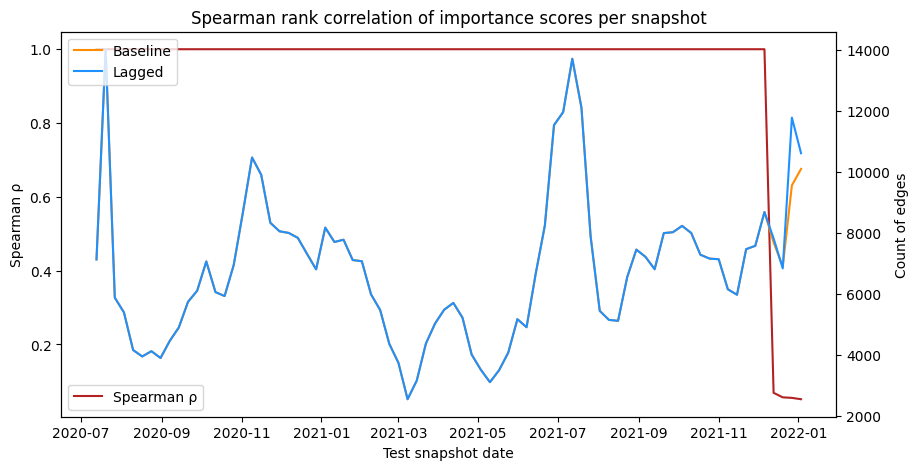

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_importance_df.date.unique(), spearman_corrs, color="firebrick", label="Spearman ρ")

ax_2 = ax.twinx()
ax_2.plot(edge_count_df.date, edge_count_df.baseline_count, label="Baseline", color="darkorange")
ax_2.plot(edge_count_df.date, edge_count_df.lagged_count, label="Lagged", color="dodgerblue")

ax.set_title("Spearman rank correlation of importance scores per snapshot")
ax.set_xlabel("Test snapshot date")
ax.set_ylabel("Spearman ρ")
ax_2.set_ylabel("Count of edges")
ax.legend(loc="lower left")
ax_2.legend(loc="upper left")
plt.show()

In [24]:
spearman_corrs[-4:]

[np.float64(0.068938709954761),
 np.float64(0.056728504394552834),
 np.float64(0.05527213334059237),
 np.float64(0.05163222582293579)]

In [25]:
baseline_importance_df["cbsa_pair"] = baseline_importance_df["cbsa_orig"].astype(str) + "_" + baseline_importance_df["cbsa_dest"].astype(str)
lagged_importance_df["cbsa_pair"] = lagged_importance_df["cbsa_orig"].astype(str) + "_" + lagged_importance_df["cbsa_dest"].astype(str)

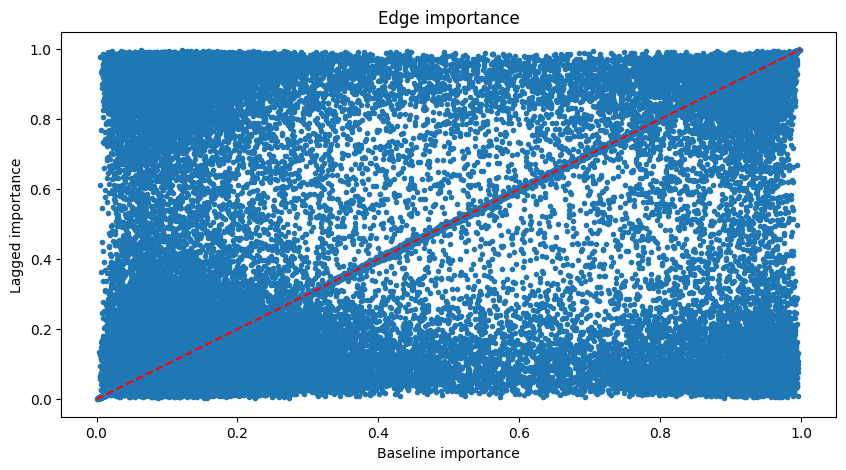

In [26]:
edge_importance_df = baseline_importance_df.merge(lagged_importance_df, on=["date", "cbsa_pair"], suffixes=("_baseline", "_lagged"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(edge_importance_df.importance_baseline, edge_importance_df.importance_lagged, '.')
ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')

ax.set_title("Edge importance")
ax.set_xlabel("Baseline importance")
ax.set_ylabel("Lagged importance")
plt.show()

In [27]:
edge_importance_df.groupby('date')[['importance_baseline', 'importance_lagged']].corr()

importance_baseline  importance_lagged
date                                                                  
2020-07-13 importance_baseline             1.000000           1.000000
           importance_lagged               1.000000           1.000000
2020-07-20 importance_baseline             1.000000           1.000000
           importance_lagged               1.000000           1.000000
2020-07-27 importance_baseline             1.000000           1.000000
...                                             ...                ...
2021-12-20 importance_lagged               0.109960           1.000000
2021-12-27 importance_baseline             1.000000           0.106965
           importance_lagged               0.106965           1.000000
2022-01-03 importance_baseline             1.000000           0.113141
           importance_lagged               0.113141           1.000000

[156 rows x 2 columns]

## Compare at node-level

In [28]:
baseline_importance_df = baseline_importance_df.loc[baseline_importance_df["split"] == "test"]
lagged_importance_df = lagged_importance_df.loc[lagged_importance_df["split"] == "test"]

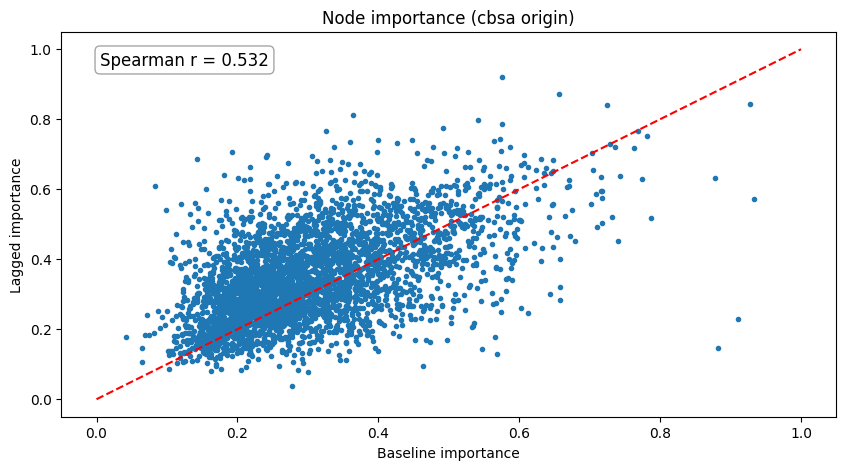

In [29]:
node_importance_df = baseline_importance_df.groupby(['date', 'cbsa_orig'])['importance'].mean().sort_values(ascending=False).reset_index().rename(columns={'importance': 'baseline_importance'}).merge(
    lagged_importance_df.groupby(['date', 'cbsa_orig'])['importance'].mean().sort_values(ascending=False).reset_index().rename(columns={'importance': 'lagged_importance'}),
    on=['date', 'cbsa_orig'],
    how='inner',
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(node_importance_df.baseline_importance, node_importance_df.lagged_importance, '.')
ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')
from scipy.stats import spearmanr

# Calculate Spearman correlation coefficient
spearman_coef, spearman_p = spearmanr(node_importance_df.baseline_importance, node_importance_df.lagged_importance)

# Annotate Spearman coefficient on the plot
ax.annotate(f"Spearman r = {spearman_coef:.3f}", xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="gray", alpha=0.7))

ax.set_title("Node importance (cbsa origin)")
ax.set_xlabel("Baseline importance")
ax.set_ylabel("Lagged importance")
plt.show()

In [30]:
np.corrcoef(node_importance_df.baseline_importance, node_importance_df.lagged_importance)

array([[1.        , 0.54550718],
       [0.54550718, 1.        ]])

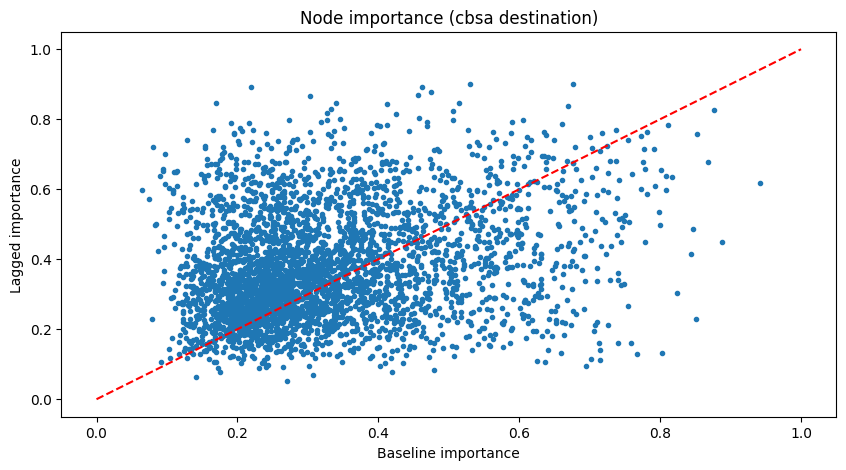

In [31]:
node_importance_df = baseline_importance_df.groupby(['date','cbsa_dest'])['importance'].mean().sort_values(ascending=False).reset_index().rename(columns={'importance': 'baseline_importance'}).merge(
    lagged_importance_df.groupby(['date','cbsa_dest'])['importance'].mean().sort_values(ascending=False).reset_index().rename(columns={'importance': 'lagged_importance'}),
    on=['date', 'cbsa_dest'],
    how='inner',
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(node_importance_df.baseline_importance, node_importance_df.lagged_importance, '.')
ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')

ax.set_title("Node importance (cbsa destination)")
ax.set_xlabel("Baseline importance")
ax.set_ylabel("Lagged importance")
plt.show()

In [25]:
np.corrcoef(node_importance_df.baseline_importance, node_importance_df.lagged_importance)

array([[1.        , 0.76359108],
       [0.76359108, 1.        ]])